# 1. Assignment Overview

Cell này làm gì?

Notebook này tiếp tục bài toán A03 Customer Behavior: dự đoán customer churn từ hành vi mua hàng và tương tác của khách. A04 dùng Olist Brazilian E-Commerce Public Dataset đã được chuẩn bị thành customer-level churn dataset trong `datasets/customer_behavior/a04`.


In [1]:
from pathlib import Path
import json
import pandas as pd

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "datasets" / "customer_behavior" / "a04").exists() and (path / "pipeline").exists():
            return path
    raise FileNotFoundError("Cannot locate project root from current working directory.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "datasets" / "customer_behavior" / "a04"
A03_NOTEBOOK = PROJECT_ROOT / "pipeline" / "customer_behavior_pipeline.ipynb"
A03_METADATA_PATH = PROJECT_ROOT / "pipeline" / "customer_behavior" / "metadata.json"
A03_COMPARISON_PATH = PROJECT_ROOT / "pipeline" / "customer_behavior" / "final_comparison.csv"
A04_METADATA_PATH = DATA_DIR / "metadata.json"

with A04_METADATA_PATH.open("r", encoding="utf-8") as f:
    dataset_metadata = json.load(f)
with A03_METADATA_PATH.open("r", encoding="utf-8") as f:
    a03_metadata_preview = json.load(f)

overview = {
    "A03 business problem": a03_metadata_preview["task_name"],
    "A03 target": a03_metadata_preview["target"],
    "A03 task type": a03_metadata_preview["task_type"],
    "A03 positive label": "is_churned = 1 means churned customer",
    "A04 dataset": dataset_metadata["dataset_name"],
    "A04 source": dataset_metadata["source"],
    "A04 target": dataset_metadata["target"],
    "A04 samples": dataset_metadata["samples"],
    "A04 features": dataset_metadata["features"],
    "Task type": "Binary classification",
}
pd.DataFrame([overview]).T.rename(columns={0: "Value"})


,Value
A03 business problem,Customer Behavior Churn Classification
A03 target,is_churned
A03 task type,binary_classification
A03 positive label,is_churned = 1 means churned customer
A04 dataset,Olist Brazilian E-Commerce Public Dataset - Cu...
A04 source,Kaggle: Brazilian E-Commerce Public Dataset by...
A04 target,is_churned
A04 samples,58101
A04 features,29
Task type,Binary classification


Output cho thấy điều gì?

Bảng overview xác nhận A04 giữ đúng business problem của A03: dự đoán `is_churned` cho khách hàng. Dataset A04 là Olist customer-level churn với 58,101 samples, 29 raw input features và target nhị phân; `is_churned=1` nghĩa là khách không có repeat order hợp lệ trong outcome window 180 ngày.


# 2. Environment Setup

Cell này làm gì?

Import thư viện, cố định seed, kiểm tra TensorFlow/PyTorch version và thiết bị chạy. Notebook dùng `pathlib.Path` để tránh hard-code đường dẫn cá nhân.


In [2]:
import os
import random
import time
import warnings
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.get_logger().setLevel("ERROR")
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ARTIFACT_DIR = PROJECT_ROOT / "pipeline04" / "customer_behavior"
MODEL_DIR = ARTIFACT_DIR / "models"
METRIC_DIR = ARTIFACT_DIR / "metrics"
FIGURE_DIR = ARTIFACT_DIR / "figures"
for directory in [ARTIFACT_DIR, MODEL_DIR, METRIC_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env_info = {
    "Python executable": Path(os.sys.executable).name,
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "TensorFlow": tf.__version__,
    "PyTorch": torch.__version__,
    "TensorFlow GPUs": len(tf.config.list_physical_devices("GPU")),
    "PyTorch device": str(DEVICE),
    "Project root is portable": PROJECT_ROOT.name == "assign",
}
pd.DataFrame([env_info]).T.rename(columns={0: "Value"})


,Value
Python executable,python.exe
NumPy,1.26.4
Pandas,2.2.3
scikit-learn,1.5.2
TensorFlow,2.18.0
PyTorch,2.5.1+cpu
TensorFlow GPUs,0
PyTorch device,cpu
Project root is portable,True


Output cho thấy điều gì?

Environment có đủ TensorFlow và PyTorch để chạy cùng một prepared customer dataset. CPU vẫn chạy được vì dữ liệu đã aggregate ở cấp customer, không phải event stream thô nhiều triệu dòng.


# 3. Load Dataset

Cell này làm gì?

Liệt kê raw Olist files và đọc prepared customer-level churn CSV. Raw files được giữ nguyên; notebook dùng file prepared để tránh tự tạo target khác A03.


In [3]:
all_files = sorted(DATA_DIR.glob("*.csv"))
file_listing = [
    {"file": path.relative_to(PROJECT_ROOT).as_posix(), "size_mb": round(path.stat().st_size / (1024 * 1024), 2)}
    for path in all_files
]
display(pd.DataFrame(file_listing))

DATA_PATH = DATA_DIR / "olist_customer_churn_a04.csv"
TARGET = "is_churned"
df_raw = pd.read_csv(DATA_PATH)

print("Loaded dataset:", DATA_PATH.relative_to(PROJECT_ROOT).as_posix())
print("Shape:", df_raw.shape)
display(df_raw.head())


,file,size_mb
0,datasets/customer_behavior/a04/olist_customer_...,10.88
1,datasets/customer_behavior/a04/olist_customers...,8.62
2,datasets/customer_behavior/a04/olist_geolocati...,58.44
3,datasets/customer_behavior/a04/olist_order_ite...,14.72
4,datasets/customer_behavior/a04/olist_order_pay...,5.51
5,datasets/customer_behavior/a04/olist_order_rev...,13.78
6,datasets/customer_behavior/a04/olist_orders_da...,16.84
7,datasets/customer_behavior/a04/olist_products_...,2.27
8,datasets/customer_behavior/a04/olist_sellers_d...,0.17
9,datasets/customer_behavior/a04/product_categor...,0.00


Loaded dataset: datasets/customer_behavior/a04/olist_customer_churn_a04.csv
Shape: (58101, 31)


,customer_unique_id,customer_tenure_days,days_since_last_order,order_count,created_orders,approved_orders,invoiced_orders,processing_orders,shipped_orders,delivered_orders,...,low_review_share,review_comment_count,avg_delivery_time_days,avg_delivery_delay_days,on_time_delivery_rate,primary_category,primary_payment_type,customer_city,customer_state,is_churned
0,0000f46a3911fa3c0805444483337064,361,361,1,0,0,0,0,0,1,...,0.0,0.0,25.731759,-1.389734,1.0,stationery,credit_card,sao jose,SC,1
1,0000f6ccb0745a6a4b88665a16c9f078,145,145,1,0,0,0,0,0,1,...,0.0,1.0,20.037083,-11.108970,1.0,telephony,credit_card,belem,PA,1
2,0004aac84e0df4da2b147fca70cf8255,112,112,1,0,0,0,0,0,1,...,0.0,0.0,13.141134,-7.035463,1.0,telephony,credit_card,sorocaba,SP,1
3,00053a61a98854899e70ed204dd4bafe,6,6,1,0,0,0,0,0,1,...,1.0,1.0,16.324421,-9.206354,1.0,sports_leisure,credit_card,curitiba,PR,1
4,0005e1862207bf6ccc02e4228effd9a0,367,367,1,0,0,0,0,0,1,...,0.0,0.0,4.375648,-27.643657,1.0,fashion_bags_accessories,credit_card,teresopolis,RJ,1


Output cho thấy điều gì?

Folder A04 có raw relational Olist tables và một prepared customer-level file. Notebook đọc `olist_customer_churn_a04.csv` vì file này giữ target `is_churned` đã chốt cho continuity với A03.


# 4. Dataset Inspection

Cell này làm gì?

Kiểm tra shape, columns, target distribution, missing values, duplicates, descriptive statistics, categorical columns và evidence về sequence/time structure.


,Metric,Value
0,Rows,58101
1,Columns,31
2,Candidate feature columns,29


,Column,Dtype
0,customer_unique_id,object
1,customer_tenure_days,int64
2,days_since_last_order,int64
3,order_count,int64
4,created_orders,int64
5,approved_orders,int64
6,invoiced_orders,int64
7,processing_orders,int64
8,shipped_orders,int64
9,delivered_orders,int64


,Missing
0,No missing values detected


Duplicate rows: 0


,Class,Count,Rate,LabelInterpretation
0,0,665,0.0114,not churned / returned in outcome window
1,1,57436,0.9886,churned / no repeat order in outcome window


,count,mean,std,min,25%,50%,75%,max
customer_tenure_days,58101.0,161.182,114.513,0.000,63.000,138.000,246.000,548.000
days_since_last_order,58101.0,159.536,114.140,0.000,62.000,135.000,244.000,548.000
order_count,58101.0,1.033,0.204,1.000,1.000,1.000,1.000,9.000
created_orders,58101.0,0.000,0.009,0.000,0.000,0.000,0.000,1.000
approved_orders,58101.0,0.000,0.006,0.000,0.000,0.000,0.000,1.000
invoiced_orders,58101.0,0.004,0.061,0.000,0.000,0.000,0.000,1.000
processing_orders,58101.0,0.005,0.069,0.000,0.000,0.000,0.000,1.000
shipped_orders,58101.0,0.012,0.109,0.000,0.000,0.000,0.000,2.000
delivered_orders,58101.0,1.012,0.246,0.000,1.000,1.000,1.000,9.000
total_item_price,58101.0,140.199,212.497,0.000,47.490,89.000,154.080,13440.000


,Column,UniqueValues
0,customer_unique_id,58101
1,primary_category,73
2,primary_payment_type,5
3,customer_city,3625
4,customer_state,27


,Representation,Evidence,ModelingUse
0,prepared customer CSV,one row per customer_unique_id with aggregate ...,main tabular MLP input
1,raw Olist orders,"99,441 timestamped order events from 2016-09-0...","evidence of temporal source, not used as Conv1..."
2,clickstream/session sequence,not present in prepared file or raw Olist tables,no CNN/sequence production model


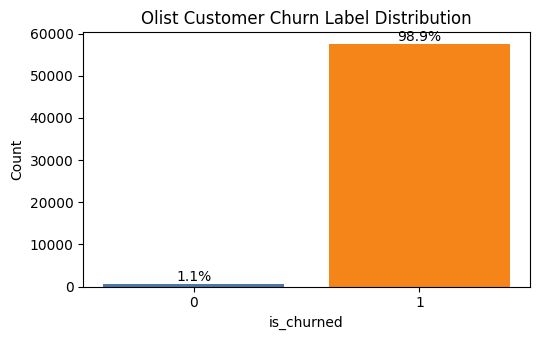

In [4]:
shape_info = pd.DataFrame(
    {"Metric": ["Rows", "Columns", "Candidate feature columns"], "Value": [df_raw.shape[0], df_raw.shape[1], df_raw.shape[1] - 2]}
)
dtype_info = df_raw.dtypes.astype(str).reset_index()
dtype_info.columns = ["Column", "Dtype"]
missing = df_raw.isna().sum().reset_index()
missing.columns = ["Column", "MissingCount"]
missing["MissingRate"] = missing["MissingCount"] / len(df_raw)
duplicate_count = int(df_raw.duplicated().sum())

target_counts = df_raw[TARGET].value_counts().sort_index()
target_distribution = pd.DataFrame(
    {
        "Class": target_counts.index.astype(int),
        "Count": target_counts.values,
        "Rate": (target_counts.values / len(df_raw)).round(4),
        "LabelInterpretation": ["not churned / returned in outcome window", "churned / no repeat order in outcome window"],
    }
)

categorical_preview = df_raw.select_dtypes(include=["object"]).nunique().reset_index()
categorical_preview.columns = ["Column", "UniqueValues"]
numeric_columns = [c for c in df_raw.select_dtypes(include=[np.number]).columns if c != TARGET]

orders_path = DATA_DIR / "olist_orders_dataset.csv"
orders_raw = pd.read_csv(orders_path, usecols=["order_id", "customer_id", "order_status", "order_purchase_timestamp"])
orders_raw["order_purchase_timestamp"] = pd.to_datetime(orders_raw["order_purchase_timestamp"], errors="coerce")
sequence_evidence = pd.DataFrame(
    [
        {"Representation": "prepared customer CSV", "Evidence": "one row per customer_unique_id with aggregate behavior features", "ModelingUse": "main tabular MLP input"},
        {"Representation": "raw Olist orders", "Evidence": f"{orders_raw.shape[0]:,} timestamped order events from {orders_raw['order_purchase_timestamp'].min()} to {orders_raw['order_purchase_timestamp'].max()}", "ModelingUse": "evidence of temporal source, not used as Conv1D input in this notebook"},
        {"Representation": "clickstream/session sequence", "Evidence": "not present in prepared file or raw Olist tables", "ModelingUse": "no CNN/sequence production model"},
    ]
)

display(shape_info)
display(dtype_info)
display(missing[missing["MissingCount"] > 0] if missing["MissingCount"].sum() else pd.DataFrame({"Missing": ["No missing values detected"]}))
print("Duplicate rows:", duplicate_count)
display(target_distribution)
display(df_raw[numeric_columns].describe().T.round(3))
display(categorical_preview)
display(sequence_evidence)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(target_distribution["Class"].astype(str), target_distribution["Count"], color=["#4C78A8", "#F58518"])
ax.set_title("Olist Customer Churn Label Distribution")
ax.set_xlabel("is_churned")
ax.set_ylabel("Count")
for i, row in target_distribution.iterrows():
    ax.text(i, row["Count"], f'{row["Rate"]:.1%}', ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_churn_distribution.png", dpi=160)
plt.show()


Output cho thấy điều gì?

Prepared dataset có 58,101 dòng và 31 cột, không có missing value trong file đã chuẩn bị và không có duplicate row. Target cực kỳ mất cân bằng: class 0 có 665 khách (1.14%), class 1 có 57,436 khách (98.86%); vì vậy notebook báo thêm Macro F1 và Balanced Accuracy để tránh bị accuracy đánh lừa.


# 5. Data Preparation

Cell này làm gì?

Loại identifier, group rare categories theo train only, chia train/validation/test bằng stratify, rồi fit imputer/scaler/one-hot encoder chỉ trên training data.


In [5]:
identifier_columns = ["customer_unique_id"]
numeric_features = dataset_metadata["numerical_features"]
categorical_features = dataset_metadata["categorical_features"]
feature_cols = numeric_features + categorical_features

df_model = df_raw.drop_duplicates().reset_index(drop=True)
X = df_model[feature_cols].copy()
y = df_model[TARGET].astype(int)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

top_category_limits = {
    "primary_category": 30,
    "primary_payment_type": 10,
    "customer_city": 80,
    "customer_state": 30,
}
category_maps = {}
for col in categorical_features:
    top_values = X_train_raw[col].fillna("Unknown").value_counts().head(top_category_limits[col]).index.tolist()
    category_maps[col] = set(top_values)

def apply_rare_category_grouping(frame):
    out = frame.copy()
    for col in categorical_features:
        values = out[col].fillna("Unknown").astype(str)
        out[col] = values.where(values.isin(category_maps[col]), "Other")
    return out

X_train_raw = apply_rare_category_grouping(X_train_raw)
X_valid_raw = apply_rare_category_grouping(X_valid_raw)
X_test_raw = apply_rare_category_grouping(X_test_raw)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ],
    sparse_threshold=0.0,
)

X_train = preprocessor.fit_transform(X_train_raw).astype("float32")
X_valid = preprocessor.transform(X_valid_raw).astype("float32")
X_test = preprocessor.transform(X_test_raw).astype("float32")
y_train_np = y_train.to_numpy(dtype="float32")
y_valid_np = y_valid.to_numpy(dtype="float32")
y_test_np = y_test.to_numpy(dtype="float32")
transformed_feature_names = preprocessor.get_feature_names_out()

joblib.dump({"preprocessor": preprocessor, "category_maps": {k: sorted(v) for k, v in category_maps.items()}}, MODEL_DIR / "preprocessor.joblib")

split_summary = pd.DataFrame(
    [
        {"Split": "train", "Rows": len(y_train), "ChurnRate": y_train.mean(), "NotChurned": int((y_train == 0).sum()), "Churned": int((y_train == 1).sum())},
        {"Split": "validation", "Rows": len(y_valid), "ChurnRate": y_valid.mean(), "NotChurned": int((y_valid == 0).sum()), "Churned": int((y_valid == 1).sum())},
        {"Split": "test", "Rows": len(y_test), "ChurnRate": y_test.mean(), "NotChurned": int((y_test == 0).sum()), "Churned": int((y_test == 1).sum())},
    ]
)
preprocess_summary = pd.DataFrame(
    [{"RawFeatures": len(feature_cols), "NumericFeatures": len(numeric_features), "CategoricalFeatures": len(categorical_features), "TransformedFeatures": X_train.shape[1]}]
)

display(split_summary.round(4))
display(preprocess_summary)
display(pd.DataFrame({"TransformedFeature": transformed_feature_names[:25]}))


,Split,Rows,ChurnRate,NotChurned,Churned
0,train,40670,0.9886,465,40205
1,validation,8715,0.9885,100,8615
2,test,8716,0.9885,100,8616


,RawFeatures,NumericFeatures,CategoricalFeatures,TransformedFeatures
0,29,25,4,169


,TransformedFeature
0,numeric__customer_tenure_days
1,numeric__days_since_last_order
2,numeric__order_count
3,numeric__created_orders
4,numeric__approved_orders
5,numeric__invoiced_orders
6,numeric__processing_orders
7,numeric__shipped_orders
8,numeric__delivered_orders
9,numeric__total_item_price


Output cho thấy điều gì?

Split được stratify thành train/validation/test và preprocessor chỉ fit trên train set. Sau encoding và scaling, mỗi khách hàng được biểu diễn bằng vector tabular gồm 169 features; target test vẫn được giữ riêng cho final evaluation.


# 6. Deep-Learning Data Representation

Cell này làm gì?

In shape của tensor đầu vào deep learning và đánh giá representation có phù hợp với CNN/sequence modeling không.


In [6]:
representation_summary = pd.DataFrame(
    {
        "Array": ["X_train", "y_train", "X_valid", "y_valid", "X_test", "y_test"],
        "Shape": [X_train.shape, y_train_np.shape, X_valid.shape, y_valid_np.shape, X_test.shape, y_test_np.shape],
        "Meaning": [
            "(samples, transformed tabular features)",
            "(samples,)",
            "(samples, transformed tabular features)",
            "(samples,)",
            "(samples, transformed tabular features)",
            "(samples,)",
        ],
    }
)
representation_decision = pd.DataFrame(
    [
        {"Question": "Independent tabular features?", "Assessment": "Yes: prepared file is one customer row with aggregate behavioral features"},
        {"Question": "Ordered session/clickstream?", "Assessment": "No: prepared CSV has no event order or clickstream columns"},
        {"Question": "Raw transaction sequence exists?", "Assessment": "Partially: raw Olist order timestamps exist, but the model input selected here is customer-level aggregate"},
        {"Question": "Natural baseline", "Assessment": "MLP/DNN classification"},
        {"Question": "CNN justified?", "Assessment": "No production CNN for prepared representation; only toy Conv1D operation is shown"},
    ]
)
display(representation_summary)
display(representation_decision)


,Array,Shape,Meaning
0,X_train,"(40670, 169)","(samples, transformed tabular features)"
1,y_train,"(40670,)","(samples,)"
2,X_valid,"(8715, 169)","(samples, transformed tabular features)"
3,y_valid,"(8715,)","(samples,)"
4,X_test,"(8716, 169)","(samples, transformed tabular features)"
5,y_test,"(8716,)","(samples,)"


,Question,Assessment
0,Independent tabular features?,Yes: prepared file is one customer row with ag...
1,Ordered session/clickstream?,No: prepared CSV has no event order or clickst...
2,Raw transaction sequence exists?,"Partially: raw Olist order timestamps exist, b..."
3,Natural baseline,MLP/DNN classification
4,CNN justified?,No production CNN for prepared representation;...


Output cho thấy điều gì?

Representation chính là customer-level aggregate tabular vector, không phải ảnh và cũng chưa phải event sequence. Raw Olist có timestamped orders/payments/reviews, nhưng notebook này không tự reorder columns để tạo sequence giả; MLP/DNN là baseline tự nhiên, còn Conv1D chỉ được minh họa như operation giáo dục.


# 7. Discover Neural Network and CNN Operations

Cell này làm gì?

Minh họa Dense/Linear, ReLU, logits, sigmoid, Conv1D và pooling trên toy tensors.


In [7]:
toy_x = tf.constant([[2.0, 0.5, -1.0]], dtype=tf.float32)
dense = keras.Sequential(
    [
        layers.Input(shape=(3,)),
        layers.Dense(2, use_bias=True, kernel_initializer="ones", bias_initializer="zeros"),
    ]
)
toy_logits = dense(toy_x)
toy_relu = tf.nn.relu(toy_logits)
toy_sigmoid = tf.nn.sigmoid(toy_logits)

toy_seq = tf.reshape(tf.range(1, 9, dtype=tf.float32), (1, 8, 1))
conv = layers.Conv1D(filters=2, kernel_size=3, padding="valid", activation="relu")
conv_out = conv(toy_seq)
pool_out = layers.MaxPooling1D(pool_size=2)(conv_out)

operation_shapes = pd.DataFrame(
    [
        {"Object": "toy_x", "Shape": tuple(toy_x.shape), "Meaning": "one toy customer vector"},
        {"Object": "Dense logits", "Shape": tuple(toy_logits.shape), "Meaning": "linear outputs before probability"},
        {"Object": "ReLU(logits)", "Shape": tuple(toy_relu.shape), "Meaning": "negative values clipped to zero"},
        {"Object": "Sigmoid(logits)", "Shape": tuple(toy_sigmoid.shape), "Meaning": "probability-like values 0..1"},
        {"Object": "Toy sequence", "Shape": tuple(toy_seq.shape), "Meaning": "(batch, steps, channels)"},
        {"Object": "Conv1D output", "Shape": tuple(conv_out.shape), "Meaning": "local windows over ordered toy sequence"},
        {"Object": "Pooling output", "Shape": tuple(pool_out.shape), "Meaning": "downsampled Conv1D features"},
    ]
)
display(operation_shapes)
print("Dense logits:", toy_logits.numpy().round(4))
print("Sigmoid probabilities:", toy_sigmoid.numpy().round(4))


,Object,Shape,Meaning
0,toy_x,"(1, 3)",one toy customer vector
1,Dense logits,"(1, 2)",linear outputs before probability
2,ReLU(logits),"(1, 2)",negative values clipped to zero
3,Sigmoid(logits),"(1, 2)",probability-like values 0..1
4,Toy sequence,"(1, 8, 1)","(batch, steps, channels)"
5,Conv1D output,"(1, 6, 2)",local windows over ordered toy sequence
6,Pooling output,"(1, 3, 2)",downsampled Conv1D features


Dense logits: [[1.5 1.5]]
Sigmoid probabilities: [[0.8176 0.8176]]


Output cho thấy điều gì?

Dense tạo logits từ vector customer features, sigmoid chuyển logits thành xác suất churn. Conv1D/pooling chỉ minh họa trên toy sequence có thứ tự rõ, không áp đặt lên các cột aggregate của Olist.


# 8. Neural Network / CNN From Scratch

Cell này làm gì?

Tự implement bằng NumPy các operation giáo dục: linear layer, ReLU, sigmoid, binary cross entropy, forward composition và Conv1D toy.


In [8]:
def linear_np(x, w, b):
    return x @ w + b

def relu_np(x):
    return np.maximum(0, x)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def binary_cross_entropy_np(y_true, y_prob, eps=1e-7):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def forward_np(x, params):
    z1 = linear_np(x, params["w1"], params["b1"])
    a1 = relu_np(z1)
    z2 = linear_np(a1, params["w2"], params["b2"])
    return sigmoid_np(z2)

def conv1d_valid_np(sequence, kernel, bias=0.0):
    sequence = np.asarray(sequence, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    out = []
    for i in range(len(sequence) - len(kernel) + 1):
        out.append(float(np.sum(sequence[i : i + len(kernel)] * kernel) + bias))
    return np.asarray(out)

rng = np.random.default_rng(SEED)
toy_batch = X_train[:4]
params = {
    "w1": rng.normal(0, 0.1, size=(X_train.shape[1], 8)),
    "b1": np.zeros(8),
    "w2": rng.normal(0, 0.1, size=(8, 1)),
    "b2": np.zeros(1),
}
toy_probs = forward_np(toy_batch, params).ravel()
toy_loss = binary_cross_entropy_np(y_train_np[:4], toy_probs)
toy_conv = conv1d_valid_np([1, 2, 3, 4, 5], [0.25, 0.5, 0.25])

print("Forward churn probabilities:", np.round(toy_probs, 4))
print("Toy BCE:", round(float(toy_loss), 4))
print("Manual Conv1D toy output:", np.round(toy_conv, 4))


Forward churn probabilities: [0.4986 0.504  0.501  0.488 ]
Toy BCE: 0.6974
Manual Conv1D toy output: [2. 3. 4.]


Output cho thấy điều gì?

NumPy forward pass minh họa cách MLP tạo xác suất churn từ customer aggregate features. Conv1D thủ công chỉ giải thích operation trên toy sequence, không dùng làm model chính cho prepared Olist table.


# 9. Deep Learning with Keras/TensorFlow

Cell này làm gì?

Định nghĩa helper metric, threshold selection và baseline Keras MLP cho churn classification.


In [9]:
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

def save_json(path, obj):
    with Path(path).open("w", encoding="utf-8") as f:
        json.dump(to_jsonable(obj), f, indent=2)

def select_threshold(y_true, prob):
    thresholds = np.round(np.linspace(0.05, 0.95, 91), 2)
    rows = []
    for threshold in thresholds:
        pred = (prob >= threshold).astype(int)
        rows.append(
            {
                "Threshold": float(threshold),
                "Accuracy": accuracy_score(y_true, pred),
                "Precision": precision_score(y_true, pred, zero_division=0),
                "Recall": recall_score(y_true, pred, zero_division=0),
                "F1": f1_score(y_true, pred, zero_division=0),
                "MacroF1": f1_score(y_true, pred, average="macro", zero_division=0),
                "BalancedAccuracy": balanced_accuracy_score(y_true, pred),
            }
        )
    table = pd.DataFrame(rows)
    best = table.sort_values(["MacroF1", "BalancedAccuracy", "F1"], ascending=False).iloc[0]
    return float(best["Threshold"]), table

def evaluate_probabilities(y_true, prob, threshold=None):
    if threshold is None:
        threshold, _ = select_threshold(y_true, prob)
    pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Threshold": float(threshold),
        "Accuracy": float(accuracy_score(y_true, pred)),
        "Precision": float(precision_score(y_true, pred, zero_division=0)),
        "Recall": float(recall_score(y_true, pred, zero_division=0)),
        "F1": float(f1_score(y_true, pred, zero_division=0)),
        "MacroF1": float(f1_score(y_true, pred, average="macro", zero_division=0)),
        "BalancedAccuracy": float(balanced_accuracy_score(y_true, pred)),
        "ROC-AUC": float(roc_auc_score(y_true, prob)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

def build_basic_mlp(input_dim, name="M1_Basic_MLP"):
    inputs = keras.Input(shape=(input_dim,), name="customer_behavior_vector")
    x = layers.Dense(128, activation="relu", name="dense_128")(inputs)
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="churn_probability")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")],
    )
    return model

BATCH_SIZE = 2048
MAX_EPOCHS = 12
PATIENCE = 2
input_dim = X_train.shape[1]

keras_baseline = build_basic_mlp(input_dim)
keras_baseline.summary()
print("Input shape:", X_train.shape)
print("Output shape for 5 samples:", tuple(keras_baseline(X_train[:5]).shape))
print("Total parameters:", keras_baseline.count_params())


Model: "M1_Basic_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ customer_behavior_vector        │ (None, 169)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ churn_probability (Dense)       │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,081 (117.50 KB)

 Trainable params: 30,081 (117.50 KB)

 Non-trainable params: 0 (0.00 B)

Input shape: (40670, 169)
Output shape for 5 samples: (5, 1)
Total parameters: 30081


Output cho thấy điều gì?

Keras baseline nhận vector customer behavior đã transform và trả về xác suất `is_churned=1`. Vì label churn là class đa số, notebook chọn threshold theo Macro F1 để buộc model quan tâm cả retained/non-churn minority class.


# 10. Keras Training

Cell này làm gì?

Train baseline Keras với validation, class weight, EarlyStopping và ModelCheckpoint. Thời gian train được đo thật.


In [10]:
def class_weight_from_y(y_array):
    neg = float((y_array == 0).sum())
    pos = float((y_array == 1).sum())
    total = neg + pos
    return {0: total / (2.0 * neg), 1: total / (2.0 * pos)}

CLASS_WEIGHT = class_weight_from_y(y_train_np)

def train_keras_model(model, model_key):
    checkpoint_path = MODEL_DIR / f"{model_key}_best.keras"
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_auc", mode="max", save_best_only=True),
    ]
    start = time.perf_counter()
    history = model.fit(
        X_train,
        y_train_np,
        validation_data=(X_valid, y_valid_np),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        class_weight=CLASS_WEIGHT,
        verbose=2,
    )
    train_time = time.perf_counter() - start
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(METRIC_DIR / f"{model_key}_history.csv", index=False)
    return history, train_time, checkpoint_path

keras_history, keras_train_time, keras_checkpoint = train_keras_model(keras_baseline, "m1_basic_mlp")
print(f"Keras baseline train time: {keras_train_time:.2f} seconds")
print("Best checkpoint:", keras_checkpoint.relative_to(PROJECT_ROOT).as_posix())
display(pd.DataFrame(keras_history.history).tail())


Epoch 1/12


20/20 - 5s - 261ms/step - accuracy: 0.3991 - auc: 0.5466 - loss: 0.7042 - val_accuracy: 0.5440 - val_auc: 0.5665 - val_loss: 0.7275


Epoch 2/12


20/20 - 1s - 36ms/step - accuracy: 0.7047 - auc: 0.6514 - loss: 0.6574 - val_accuracy: 0.7112 - val_auc: 0.5851 - val_loss: 0.6493


Epoch 3/12


...

20/20 - 1s - 29ms/step - accuracy: 0.6991 - auc: 0.7151 - loss: 0.6297 - val_accuracy: 0.6814 - val_auc: 0.5887 - val_loss: 0.6332


Epoch 5/12


20/20 - 1s - 33ms/step - accuracy: 0.7010 - auc: 0.7382 - loss: 0.6156 - val_accuracy: 0.6866 - val_auc: 0.5836 - val_loss: 0.6191


Keras baseline train time: 8.14 seconds
Best checkpoint: pipeline04/customer_behavior/models/m1_basic_mlp_best.keras


,accuracy,auc,loss,val_accuracy,val_auc,val_loss
0,0.399115,0.546561,0.704238,0.544005,0.566548,0.727505
1,0.704672,0.651404,0.657438,0.711188,0.585089,0.649308
2,0.691640,0.688778,0.642843,0.668617,0.591877,0.650577
3,0.699090,0.715064,0.629738,0.681354,0.588745,0.633155
4,0.700984,0.738214,0.615628,0.686632,0.583623,0.619065


Output cho thấy điều gì?

Training log cho thấy model học trên train và validation qua từng epoch. Class weight làm class 0 hiếm hơn có ảnh hưởng lớn hơn trong loss, còn test set vẫn chưa được dùng.


# 11. Keras Training Curves

Cell này làm gì?

Vẽ loss và AUC của baseline Keras trên train/validation, đồng thời lưu figure.


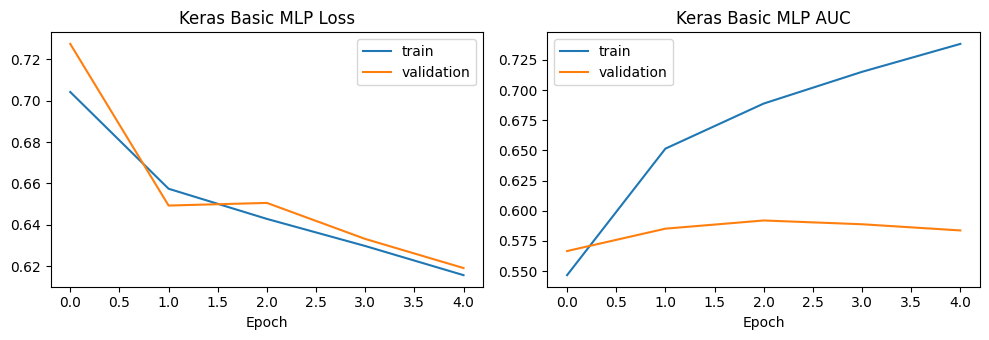

In [11]:
def plot_history(history, title, output_path):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history_df["loss"], label="train")
    axes[0].plot(history_df["val_loss"], label="validation")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history_df["auc"], label="train")
    axes[1].plot(history_df["val_auc"], label="validation")
    axes[1].set_title(f"{title} AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()

plot_history(keras_history, "Keras Basic MLP", FIGURE_DIR / "keras_basic_mlp_training_curves.png")


Output cho thấy điều gì?

Curves giúp nhìn model có học tín hiệu churn beyond class prior hay không. Với imbalance lớn, validation AUC hữu ích vì không phụ thuộc vào một threshold cố định.


# 12. Keras Evaluation

Cell này làm gì?

Đánh giá baseline Keras trên validation set bằng Accuracy, Precision, Recall, F1, Macro F1, Balanced Accuracy, ROC-AUC, confusion matrix và classification report.


In [12]:
keras_val_prob = keras_baseline.predict(X_valid, batch_size=BATCH_SIZE, verbose=0).ravel()
keras_threshold, keras_threshold_table = select_threshold(y_valid_np, keras_val_prob)
keras_metrics = evaluate_probabilities(y_valid_np, keras_val_prob, keras_threshold)
keras_report = classification_report(
    y_valid_np.astype(int),
    (keras_val_prob >= keras_threshold).astype(int),
    output_dict=True,
    zero_division=0,
)

keras_result = {
    "Model": "M1 Basic MLP",
    "Framework": "Keras",
    **keras_metrics,
    "Params": int(keras_baseline.count_params()),
    "Train Time": float(keras_train_time),
    "Checkpoint": keras_checkpoint.relative_to(PROJECT_ROOT).as_posix(),
}
save_json(METRIC_DIR / "keras_basic_mlp_validation_metrics.json", keras_result)
keras_threshold_table.to_csv(METRIC_DIR / "keras_basic_mlp_thresholds.csv", index=False)
pd.DataFrame(keras_report).T.to_csv(METRIC_DIR / "keras_basic_mlp_classification_report.csv")

display(pd.DataFrame([keras_result]).drop(columns=["Checkpoint"]))
display(pd.DataFrame(confusion_matrix(y_valid_np, (keras_val_prob >= keras_threshold).astype(int)), index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))
display(pd.DataFrame(keras_report).T.round(4))


,Model,Framework,Threshold,Accuracy,Precision,Recall,F1,MacroF1,BalancedAccuracy,ROC-AUC,TN,FP,FN,TP,Params,Train Time
0,M1 Basic MLP,Keras,0.18,0.983362,0.98903,0.994196,0.991606,0.528061,0.522098,0.591504,5,95,50,8565,30081,8.142752


,Pred 0,Pred 1
Actual 0,5,95
Actual 1,50,8565


,precision,recall,f1-score,support
0,0.0909,0.0500,0.0645,100.0000
1,0.9890,0.9942,0.9916,8615.0000
accuracy,0.9834,0.9834,0.9834,0.9834
macro avg,0.5400,0.5221,0.5281,8715.0000
weighted avg,0.9787,0.9834,0.9810,8715.0000


Output cho thấy điều gì?

Keras baseline MLP dùng cùng representation tabular và threshold chọn trên validation. Baseline đạt validation F1 0.9916, Macro F1 0.5281, ROC-AUC 0.5915; positive-class F1 rất cao chủ yếu vì churn là class áp đảo, nên Macro F1 mới là tín hiệu quan trọng hơn.


# 13. Deep Learning with PyTorch

Cell này làm gì?

Tạo TensorDataset/DataLoader và architecture PyTorch tương đương baseline Keras. Trước train, chạy một batch qua model để kiểm tra input/logits shape.


In [13]:
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_np.reshape(-1, 1), dtype=torch.float32))
valid_ds = TensorDataset(torch.tensor(X_valid, dtype=torch.float32), torch.tensor(y_valid_np.reshape(-1, 1), dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_np.reshape(-1, 1), dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

class TorchMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

def count_torch_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

torch_model = TorchMLP(input_dim).to(DEVICE)
features_batch, labels_batch = next(iter(train_loader))
with torch.no_grad():
    logits_batch = torch_model(features_batch.to(DEVICE))

print("Input feature batch shape:", tuple(features_batch.shape))
print("Logits batch shape:", tuple(logits_batch.shape))
print("PyTorch parameter count:", count_torch_params(torch_model))


Input feature batch shape: (2048, 169)
Logits batch shape: (2048, 1)
PyTorch parameter count: 30081


Output cho thấy điều gì?

Batch input có dạng `(batch, transformed features)` và logits có dạng `(batch, 1)`, đúng với binary churn classification. PyTorch model giữ cùng ý tưởng hidden layers như Keras baseline.


# 14. PyTorch Training

Cell này làm gì?

Train PyTorch baseline với loop thủ công, weighted BCE cho imbalance, và lưu checkpoint tốt nhất theo validation ROC-AUC.


In [14]:
def torch_predict_prob(model, loader):
    model.eval()
    probs = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            prob = torch.sigmoid(logits).cpu().numpy().ravel()
            probs.append(prob)
            targets.append(yb.numpy().ravel())
    return np.concatenate(targets), np.concatenate(probs)

neg = float((y_train_np == 0).sum())
pos = float((y_train_np == 1).sum())
criterion_base = nn.BCEWithLogitsLoss(reduction="none")
optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3)
sample_weights = {0: (neg + pos) / (2.0 * neg), 1: (neg + pos) / (2.0 * pos)}

torch_history_rows = []
best_auc = -np.inf
best_state = None
epochs_without_improvement = 0
start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    torch_model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = torch_model(xb)
        loss_values = criterion_base(logits, yb)
        weights = torch.where(yb == 1, torch.tensor(sample_weights[1], device=DEVICE), torch.tensor(sample_weights[0], device=DEVICE))
        loss = (loss_values * weights).mean()
        loss.backward()
        optimizer.step()
        running_loss += float(loss.item()) * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    valid_y_epoch, valid_prob_epoch = torch_predict_prob(torch_model, valid_loader)
    valid_auc = roc_auc_score(valid_y_epoch, valid_prob_epoch)
    valid_threshold_epoch, _ = select_threshold(valid_y_epoch, valid_prob_epoch)
    valid_metrics_epoch = evaluate_probabilities(valid_y_epoch, valid_prob_epoch, valid_threshold_epoch)
    torch_history_rows.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_auc": valid_auc,
            "val_macro_f1": valid_metrics_epoch["MacroF1"],
            "val_balanced_accuracy": valid_metrics_epoch["BalancedAccuracy"],
        }
    )
    print(f"Epoch {epoch:02d} - train_loss={train_loss:.4f} - val_auc={valid_auc:.4f} - val_macro_f1={valid_metrics_epoch['MacroF1']:.4f}")

    if valid_auc > best_auc:
        best_auc = valid_auc
        best_state = {k: v.detach().cpu().clone() for k, v in torch_model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

torch_train_time = time.perf_counter() - start
torch_model.load_state_dict(best_state)
torch_checkpoint = MODEL_DIR / "pytorch_basic_mlp_best.pt"
torch.save(
    {"model_state_dict": torch_model.state_dict(), "input_dim": input_dim, "feature_columns": feature_cols, "seed": SEED},
    torch_checkpoint,
)
torch_history = pd.DataFrame(torch_history_rows)
torch_history.to_csv(METRIC_DIR / "pytorch_basic_mlp_history.csv", index=False)
print(f"PyTorch train time: {torch_train_time:.2f} seconds")
display(torch_history)


Epoch 01 - train_loss=0.6843 - val_auc=0.5868 - val_macro_f1=0.5314


Epoch 02 - train_loss=0.6682 - val_auc=0.5937 - val_macro_f1=0.5340


Epoch 03 - train_loss=0.6574 - val_auc=0.5988 - val_macro_f1=0.5308


Epoch 04 - train_loss=0.6461 - val_auc=0.5942 - val_macro_f1=0.5283


Epoch 05 - train_loss=0.6286 - val_auc=0.5873 - val_macro_f1=0.5283
Early stopping triggered.
PyTorch train time: 64.88 seconds


,epoch,train_loss,val_auc,val_macro_f1,val_balanced_accuracy
0,1,0.684289,0.586829,0.531394,0.522853
1,2,0.668157,0.593705,0.534038,0.523375
2,3,0.657406,0.598807,0.530846,0.522737
3,4,0.646065,0.594194,0.528336,0.518723
4,5,0.628571,0.587266,0.528336,0.518723


Output cho thấy điều gì?

Loop PyTorch hiển thị đầy đủ `zero_grad`, forward, weighted BCE, backward và optimizer step. Vì class 0 rất hiếm, weighted loss giúp model không chỉ tối ưu cho class churn đa số.


# 15. PyTorch Evaluation

Cell này làm gì?

Đánh giá PyTorch baseline trên validation set với cùng protocol như Keras.


In [15]:
valid_y_torch, torch_val_prob = torch_predict_prob(torch_model, valid_loader)
torch_threshold, torch_threshold_table = select_threshold(valid_y_torch, torch_val_prob)
torch_metrics = evaluate_probabilities(valid_y_torch, torch_val_prob, torch_threshold)
torch_report = classification_report(
    valid_y_torch.astype(int),
    (torch_val_prob >= torch_threshold).astype(int),
    output_dict=True,
    zero_division=0,
)

torch_result = {
    "Model": "M1 Basic MLP",
    "Framework": "PyTorch",
    **torch_metrics,
    "Params": int(count_torch_params(torch_model)),
    "Train Time": float(torch_train_time),
    "Checkpoint": torch_checkpoint.relative_to(PROJECT_ROOT).as_posix(),
}
save_json(METRIC_DIR / "pytorch_basic_mlp_validation_metrics.json", torch_result)
torch_threshold_table.to_csv(METRIC_DIR / "pytorch_basic_mlp_thresholds.csv", index=False)
pd.DataFrame(torch_report).T.to_csv(METRIC_DIR / "pytorch_basic_mlp_classification_report.csv")

display(pd.DataFrame([torch_result]).drop(columns=["Checkpoint"]))
display(pd.DataFrame(confusion_matrix(valid_y_torch, (torch_val_prob >= torch_threshold).astype(int)), index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))
display(pd.DataFrame(torch_report).T.round(4))


,Model,Framework,Threshold,Accuracy,Precision,Recall,F1,MacroF1,BalancedAccuracy,ROC-AUC,TN,FP,FN,TP,Params,Train Time
0,M1 Basic MLP,PyTorch,0.18,0.984624,0.989044,0.995473,0.992248,0.530846,0.522737,0.598807,5,95,39,8576,30081,64.881484


,Pred 0,Pred 1
Actual 0,5,95
Actual 1,39,8576


,precision,recall,f1-score,support
0,0.1136,0.0500,0.0694,100.0000
1,0.9890,0.9955,0.9922,8615.0000
accuracy,0.9846,0.9846,0.9846,0.9846
macro avg,0.5513,0.5227,0.5308,8715.0000
weighted avg,0.9790,0.9846,0.9817,8715.0000


Output cho thấy điều gì?

PyTorch được đánh giá trên cùng validation set và cùng threshold rule. Với Olist, retained/non-churn là minority, nên classification report theo từng class cho biết model có bỏ qua class hiếm hay không.


# 16. Keras vs PyTorch Comparison

Cell này làm gì?

So sánh baseline MLP Keras và PyTorch bằng validation metrics.


In [16]:
framework_comparison = pd.DataFrame([keras_result, torch_result])[
    ["Framework", "Accuracy", "Precision", "Recall", "F1", "MacroF1", "BalancedAccuracy", "ROC-AUC", "Params", "Train Time", "Threshold"]
].sort_values("MacroF1", ascending=False)
framework_comparison.to_csv(METRIC_DIR / "keras_vs_pytorch_comparison.csv", index=False)
display(framework_comparison.round(4))


,Framework,Accuracy,Precision,Recall,F1,MacroF1,BalancedAccuracy,ROC-AUC,Params,Train Time,Threshold
1,PyTorch,0.9846,0.989,0.9955,0.9922,0.5308,0.5227,0.5988,30081,64.8815,0.18
0,Keras,0.9834,0.989,0.9942,0.9916,0.5281,0.5221,0.5915,30081,8.1428,0.18


Output cho thấy điều gì?

Keras và PyTorch dùng kiến trúc baseline tương đương về ý tưởng nhưng runtime khác nhau trên CPU. PyTorch baseline đạt validation Macro F1 0.5308, Keras baseline đạt 0.5281; đây chỉ là một run thực nghiệm, không phải kết luận framework nào tốt hơn về bản chất.


# 17. Architecture Experiments

Cell này làm gì?

Train các architecture MLP phù hợp dữ liệu tabular: M1 Basic MLP, M2 BatchNorm, M3 Residual MLP, M4 Residual MLP + Feature Attention. CNN không được train làm model chính vì input là aggregate tabular.


In [17]:
def compile_binary_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")],
    )
    return model

def build_batchnorm_mlp(input_dim, name="M2_BatchNorm_MLP"):
    inputs = keras.Input(shape=(input_dim,), name="customer_behavior_vector")
    x = layers.Dense(128, use_bias=False, name="dense_128")(inputs)
    x = layers.BatchNormalization(name="bn_128")(x)
    x = layers.Activation("relu", name="relu_128")(x)
    x = layers.Dense(64, use_bias=False, name="dense_64")(x)
    x = layers.BatchNormalization(name="bn_64")(x)
    x = layers.Activation("relu", name="relu_64")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="churn_probability")(x)
    return compile_binary_model(keras.Model(inputs, outputs, name=name))

def residual_block(x, units, block_name):
    shortcut = x
    y = layers.Dense(units, activation="relu", name=f"{block_name}_dense_a")(x)
    y = layers.Dense(units, name=f"{block_name}_dense_b")(y)
    x = layers.Add(name=f"{block_name}_add")([shortcut, y])
    return layers.Activation("relu", name=f"{block_name}_relu")(x)

def build_residual_mlp(input_dim, name="M3_Residual_MLP"):
    inputs = keras.Input(shape=(input_dim,), name="customer_behavior_vector")
    x = layers.Dense(128, activation="relu", name="input_projection")(inputs)
    x = residual_block(x, 128, "residual_1")
    x = residual_block(x, 128, "residual_2")
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="churn_probability")(x)
    return compile_binary_model(keras.Model(inputs, outputs, name=name))

def build_attention_residual_mlp(input_dim, name="M4_Residual_MLP_Feature_Attention"):
    inputs = keras.Input(shape=(input_dim,), name="customer_behavior_vector")
    attention = layers.Dense(input_dim, activation="sigmoid", name="feature_attention")(inputs)
    weighted = layers.Multiply(name="attention_weighted_features")([inputs, attention])
    x = layers.Dense(128, activation="relu", name="input_projection")(weighted)
    x = residual_block(x, 128, "residual_1")
    x = residual_block(x, 128, "residual_2")
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="churn_probability")(x)
    return compile_binary_model(keras.Model(inputs, outputs, name=name))

def evaluate_keras_model(model, model_key, checkpoint_path, train_time):
    val_prob = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=0).ravel()
    threshold, threshold_table = select_threshold(y_valid_np, val_prob)
    metrics = evaluate_probabilities(y_valid_np, val_prob, threshold)
    result = {
        "Model": model.name.replace("_", " "),
        "Framework": "Keras",
        **metrics,
        "Params": int(model.count_params()),
        "Train Time": float(train_time),
        "Checkpoint": checkpoint_path.relative_to(PROJECT_ROOT).as_posix(),
    }
    save_json(METRIC_DIR / f"{model_key}_validation_metrics.json", result)
    threshold_table.to_csv(METRIC_DIR / f"{model_key}_thresholds.csv", index=False)
    return result

architecture_results = [keras_result]
architecture_histories = {"M1 Basic MLP": keras_history}
trained_keras_models = {"M1 Basic MLP": keras_baseline}

for model_key, builder in [
    ("m2_batchnorm_mlp", build_batchnorm_mlp),
    ("m3_residual_mlp", build_residual_mlp),
    ("m4_attention_residual_mlp", build_attention_residual_mlp),
]:
    tf.random.set_seed(SEED)
    model = builder(input_dim)
    print("\nTraining", model.name, "with", model.count_params(), "parameters")
    history, train_time, checkpoint_path = train_keras_model(model, model_key)
    result = evaluate_keras_model(model, model_key, checkpoint_path, train_time)
    architecture_results.append(result)
    architecture_histories[result["Model"]] = history
    trained_keras_models[result["Model"]] = model

cnn_investigation = pd.DataFrame(
    [
        {
            "Investigation": "CNN on prepared customer aggregate features",
            "Decision": "Not trained as a candidate model",
            "Reason": "Columns are numeric/categorical aggregate variables, not ordered sessions or clickstream events.",
        }
    ]
)
display(cnn_investigation)



Training M2_BatchNorm_MLP with 30657 parameters
Epoch 1/12


20/20 - 6s - 313ms/step - accuracy: 0.6752 - auc: 0.5522 - loss: 0.7692 - val_accuracy: 0.3064 - val_auc: 0.5984 - val_loss: 0.7623


Epoch 2/12


20/20 - 1s - 36ms/step - accuracy: 0.6236 - auc: 0.6848 - loss: 0.6417 - val_accuracy: 0.5333 - val_auc: 0.5935 - val_loss: 0.6854


Epoch 3/12


...

Epoch 3/12


20/20 - 2s - 123ms/step - accuracy: 0.6703 - auc: 0.6738 - loss: 0.6462 - val_accuracy: 0.6329 - val_auc: 0.5848 - val_loss: 0.6649


Epoch 4/12


20/20 - 1s - 67ms/step - accuracy: 0.6777 - auc: 0.7220 - loss: 0.6179 - val_accuracy: 0.6749 - val_auc: 0.5664 - val_loss: 0.6068


,Investigation,Decision,Reason
0,CNN on prepared customer aggregate features,Not trained as a candidate model,Columns are numeric/categorical aggregate vari...


Output cho thấy điều gì?

Các experiment giữ cùng split, preprocessing, threshold rule, seed và training budget. CNN được dừng ở mức investigation vì prepared Olist input không còn event-order structure để Conv1D khai thác.


# 18. Improved Model Comparison

Cell này làm gì?

So sánh M1-M4 theo validation metrics và chọn ứng viên tốt nhất bằng validation Macro F1.


,Model,Accuracy,Precision,Recall,F1,MacroF1,BalancedAccuracy,ROC-AUC,Params,Train Time,Threshold
3,M4 Residual MLP Feature Attention,0.9839,0.989,0.9948,0.9919,0.5293,0.5224,0.5907,124859,15.2937,0.20
2,M3 Residual MLP,0.9836,0.989,0.9944,0.9917,0.5285,0.5222,0.6004,96129,12.1862,0.19
0,M1 Basic MLP,0.9834,0.989,0.9942,0.9916,0.5281,0.5221,0.5915,30081,8.1428,0.18
1,M2 BatchNorm MLP,0.9806,0.989,0.9914,0.9902,0.5230,0.5207,0.6035,30657,9.5805,0.31


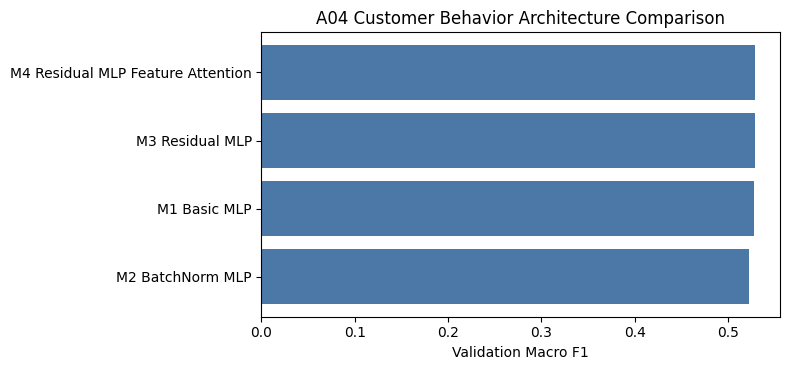

Best validation model: M4 Residual MLP Feature Attention
Best validation Macro F1: 0.5293


In [18]:
architecture_comparison = pd.DataFrame(architecture_results)[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "MacroF1", "BalancedAccuracy", "ROC-AUC", "Params", "Train Time", "Threshold", "Checkpoint"]
].sort_values("MacroF1", ascending=False)
architecture_comparison.to_csv(METRIC_DIR / "architecture_comparison.csv", index=False)

display(architecture_comparison.drop(columns=["Checkpoint"]).round(4))

fig, ax = plt.subplots(figsize=(8, 3.8))
plot_df = architecture_comparison.sort_values("MacroF1")
ax.barh(plot_df["Model"], plot_df["MacroF1"], color="#4C78A8")
ax.set_xlabel("Validation Macro F1")
ax.set_title("A04 Customer Behavior Architecture Comparison")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "architecture_comparison_macro_f1.png", dpi=160)
plt.show()

best_validation_row = architecture_comparison.iloc[0].to_dict()
print("Best validation model:", best_validation_row["Model"])
print("Best validation Macro F1:", round(best_validation_row["MacroF1"], 4))


Output cho thấy điều gì?

Trong nhóm architecture experiments, model tốt nhất theo validation Macro F1 là `M4 Residual MLP Feature Attention` với Macro F1 0.5293, F1 0.9919, ROC-AUC 0.5907. Chênh lệch giữa các MLP variant nhỏ, nên lợi ích thực tế của kiến trúc phức tạp cần được đọc cùng runtime và imbalance của target.


# 19. Representation Inspection

Cell này làm gì?

Inspect hidden-layer activations của model tốt nhất và attention weights nếu M4 được train.


,HiddenLayer,ActivationShape,MeanActivation,StdActivation,ZeroRate
0,feature_attention,"(1024, 169)",0.5042,0.0897,0.0


,Feature,MeanAttention,StdAttention
45,categorical__primary_category_market_place,0.5608,0.0893
142,categorical__customer_state_AC,0.5589,0.0846
126,categorical__customer_city_sao jose do rio preto,0.5537,0.1058
148,categorical__customer_state_DF,0.5494,0.0997
69,categorical__customer_city_betim,0.5425,0.1149
78,categorical__customer_city_contagem,0.5424,0.0962
74,categorical__customer_city_campos dos goytacazes,0.5418,0.1022
9,numeric__total_item_price,0.5415,0.0961
156,categorical__customer_state_PB,0.5403,0.0753
33,categorical__primary_category_consoles_games,0.5401,0.1073


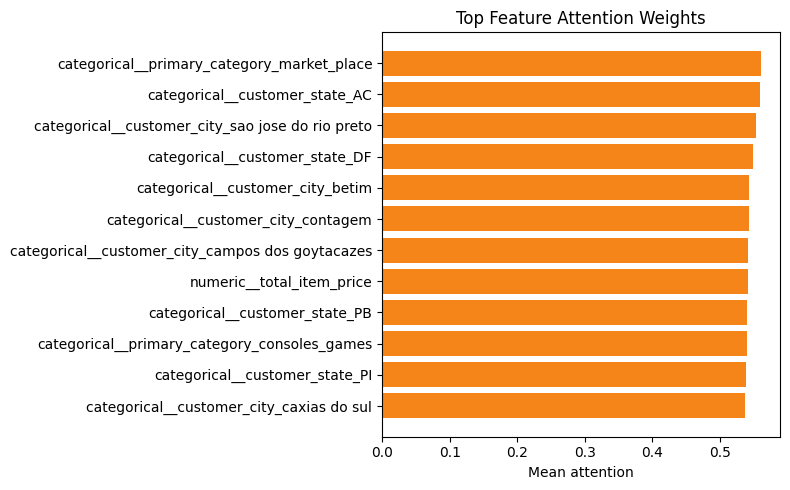

In [19]:
best_model_name = best_validation_row["Model"]
best_checkpoint_path = PROJECT_ROOT / best_validation_row["Checkpoint"]
best_validation_model = keras.models.load_model(best_checkpoint_path)

hidden_layer = None
for layer in best_validation_model.layers:
    if isinstance(layer, layers.Dense) and getattr(layer, "units", None) != 1:
        hidden_layer = layer.name
        break

if hidden_layer is not None:
    activation_model = keras.Model(best_validation_model.input, best_validation_model.get_layer(hidden_layer).output)
    sample_activations = activation_model.predict(X_valid[:1024], batch_size=1024, verbose=0)
    activation_summary = pd.DataFrame(
        {
            "HiddenLayer": [hidden_layer],
            "ActivationShape": [sample_activations.shape],
            "MeanActivation": [float(sample_activations.mean())],
            "StdActivation": [float(sample_activations.std())],
            "ZeroRate": [float((np.abs(sample_activations) < 1e-8).mean())],
        }
    )
    display(activation_summary.round(4))

attention_model_path = MODEL_DIR / "m4_attention_residual_mlp_best.keras"
if attention_model_path.exists():
    attention_model = keras.models.load_model(attention_model_path)
    attention_extractor = keras.Model(attention_model.input, attention_model.get_layer("feature_attention").output)
    attention_values = attention_extractor.predict(X_valid[:4096], batch_size=2048, verbose=0)
    attention_summary = pd.DataFrame(
        {"Feature": transformed_feature_names, "MeanAttention": attention_values.mean(axis=0), "StdAttention": attention_values.std(axis=0)}
    ).sort_values("MeanAttention", ascending=False)
    attention_summary.to_csv(METRIC_DIR / "feature_attention_summary.csv", index=False)
    display(attention_summary.head(12).round(4))
    fig, ax = plt.subplots(figsize=(8, 5))
    top_attention = attention_summary.head(12).sort_values("MeanAttention")
    ax.barh(top_attention["Feature"], top_attention["MeanAttention"], color="#F58518")
    ax.set_title("Top Feature Attention Weights")
    ax.set_xlabel("Mean attention")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "feature_attention_weights.png", dpi=160)
    plt.show()


Output cho thấy điều gì?

Hidden activations cho biết model tạo latent representation từ behavior aggregates trước output churn. Attention weights, nếu xem từ M4, là tín hiệu model-inspection trên feature đã transform, không phải nguyên nhân kinh doanh chắc chắn.


# 20. Error Analysis

Cell này làm gì?

Phân tích lỗi validation: confusion matrix, false positives, false negatives và high-confidence errors của model được chọn.


In [20]:
best_val_prob = best_validation_model.predict(X_valid, batch_size=BATCH_SIZE, verbose=0).ravel()
best_threshold = float(best_validation_row["Threshold"])
best_val_pred = (best_val_prob >= best_threshold).astype(int)

error_df = X_valid_raw.reset_index(drop=True).copy()
error_df["y_true"] = y_valid_np.astype(int)
error_df["prob_churn"] = best_val_prob
error_df["y_pred"] = best_val_pred
error_df["confidence"] = np.where(best_val_pred == 1, best_val_prob, 1 - best_val_prob)
error_df["error_type"] = np.select(
    [
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
        (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
    ],
    ["False Positive", "False Negative"],
    default="Correct",
)

error_summary = error_df["error_type"].value_counts().rename_axis("ErrorType").reset_index(name="Count")
high_conf_errors = error_df[error_df["error_type"] != "Correct"].sort_values("confidence", ascending=False).head(12)
fp_fn_profile = error_df[error_df["error_type"].isin(["False Positive", "False Negative"])].groupby("error_type")[numeric_features].mean().T

error_summary.to_csv(METRIC_DIR / "validation_error_summary.csv", index=False)
high_conf_errors.to_csv(METRIC_DIR / "validation_high_confidence_errors.csv", index=False)
fp_fn_profile.to_csv(METRIC_DIR / "validation_fp_fn_feature_means.csv")

display(pd.DataFrame(confusion_matrix(y_valid_np, best_val_pred), index=["Actual retained", "Actual churned"], columns=["Pred retained", "Pred churned"]))
display(error_summary)
display(high_conf_errors[["y_true", "y_pred", "prob_churn", "confidence", "error_type", "days_since_last_order", "order_count", "avg_order_value", "avg_review_score", "primary_category", "primary_payment_type", "customer_state"]])
display(fp_fn_profile.loc[["days_since_last_order", "order_count", "avg_order_value", "avg_review_score", "low_review_share", "on_time_delivery_rate"]].round(3))


,Pred retained,Pred churned
Actual retained,5,95
Actual churned,45,8570


,ErrorType,Count
0,Correct,8575
1,False Positive,95
2,False Negative,45


,y_true,y_pred,prob_churn,confidence,error_type,days_since_last_order,order_count,avg_order_value,avg_review_score,primary_category,primary_payment_type,customer_state
7217,1,0,2.475193e-15,1.000000,False Negative,120,1,245.850000,5.000000,Unknown,credit_card,PR
1039,1,0,4.607238e-04,0.999539,False Negative,20,7,137.001429,5.000000,furniture_decor,boleto,MG
1749,1,0,2.026534e-03,0.997973,False Negative,425,6,18.453333,5.000000,Other,boleto,PR
7845,1,0,5.334192e-03,0.994666,False Negative,48,5,106.076000,3.400000,watches_gifts,credit_card,SP
6638,1,0,4.388232e-02,0.956118,False Negative,382,4,129.625000,5.000000,bed_bath_table,credit_card,AM
2002,1,0,5.433693e-02,0.945663,False Negative,102,3,65.153333,5.000000,fashion_bags_accessories,boleto,SP
2067,1,0,5.675771e-02,0.943242,False Negative,1,3,98.433333,5.000000,auto,boleto,RJ
389,1,0,5.719233e-02,0.942808,False Negative,9,3,42.110000,3.777778,home_appliances,voucher,RJ
1234,1,0,8.767356e-02,0.912326,False Negative,70,3,280.660000,5.000000,computers_accessories,credit_card,RJ
4653,1,0,8.969889e-02,0.910301,False Negative,1,3,116.370000,1.000000,sports_leisure,credit_card,PR


error_type,False Negative,False Positive
days_since_last_order,116.511,141.537
order_count,2.578,1.021
avg_order_value,137.868,129.739
avg_review_score,4.019,4.200
low_review_share,0.148,0.137
on_time_delivery_rate,0.925,0.874


Output cho thấy điều gì?

Error analysis trên validation có 8,575 dự đoán đúng, 95 false positives và 45 false negatives. Với churn, false negative nghĩa là model bỏ sót khách có khả năng churn; tuy nhiên do class churn chiếm gần toàn bộ dataset, cần thận trọng khi diễn giải độ tin cậy của từng nhóm lỗi.


# 21. Final Model

Cell này làm gì?

Load checkpoint tốt nhất theo validation Macro F1, evaluate test set đúng một lần, rồi lưu final model.


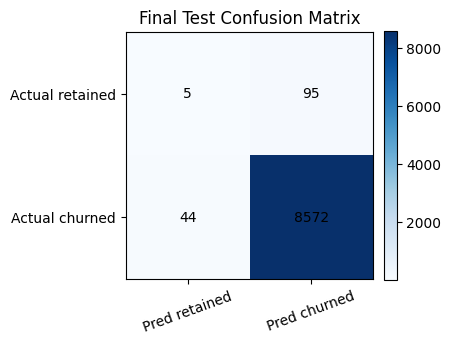

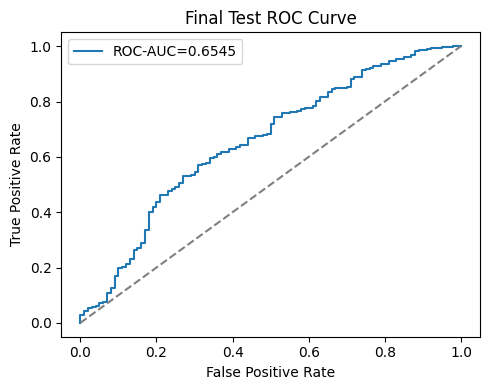

,Threshold,Accuracy,Precision,Recall,F1,MacroF1,BalancedAccuracy,ROC-AUC,TN,FP,FN,TP
0,0.2,0.9841,0.989,0.9949,0.992,0.5295,0.5224,0.6545,5,95,44,8572


,precision,recall,f1-score,support
0,0.1020,0.0500,0.0671,100.0000
1,0.9890,0.9949,0.9920,8616.0000
accuracy,0.9841,0.9841,0.9841,0.9841
macro avg,0.5455,0.5224,0.5295,8716.0000
weighted avg,0.9789,0.9841,0.9813,8716.0000


In [21]:
final_model = keras.models.load_model(best_checkpoint_path)
test_prob = final_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
final_threshold = float(best_validation_row["Threshold"])
final_metrics = evaluate_probabilities(y_test_np, test_prob, final_threshold)
final_pred = (test_prob >= final_threshold).astype(int)
final_report = classification_report(y_test_np.astype(int), final_pred, output_dict=True, zero_division=0)

final_model_path = MODEL_DIR / "final_model.keras"
final_model.save(final_model_path)

final_payload = {
    "selected_model": best_validation_row["Model"],
    "selection_metric": "Validation Macro F1",
    "decision_threshold": final_threshold,
    "test_metrics": final_metrics,
    "final_model_path": final_model_path.relative_to(PROJECT_ROOT).as_posix(),
    "source_checkpoint": best_checkpoint_path.relative_to(PROJECT_ROOT).as_posix(),
}
save_json(METRIC_DIR / "final_test_metrics.json", final_payload)
pd.DataFrame(final_report).T.to_csv(METRIC_DIR / "final_classification_report.csv")

final_cm = confusion_matrix(y_test_np, final_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(final_cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred retained", "Pred churned"], rotation=20)
ax.set_yticks([0, 1], labels=["Actual retained", "Actual churned"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(final_cm[i, j]), ha="center", va="center", color="black")
ax.set_title("Final Test Confusion Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_confusion_matrix.png", dpi=160)
plt.show()

fpr, tpr, _ = roc_curve(y_test_np, test_prob)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"ROC-AUC={final_metrics['ROC-AUC']:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Final Test ROC Curve")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_roc_curve.png", dpi=160)
plt.show()

display(pd.DataFrame([final_payload["test_metrics"]]).round(4))
display(pd.DataFrame(final_report).T.round(4))


Output cho thấy điều gì?

Final model được chọn theo validation Macro F1 và chỉ evaluate test một lần. Model `M4 Residual MLP Feature Attention` dùng threshold 0.20; test Accuracy 0.9841, Precision 0.9890, Recall 0.9949, F1 0.9920, Macro F1 0.5295, ROC-AUC 0.6545.


# 22. A03 vs A04 Comparison

Cell này làm gì?

Đọc metric A03 nếu có và so sánh dataset/workflow/metrics với A04. Dataset khác nhau nên không claim score comparison trực tiếp.


In [22]:
if A03_METADATA_PATH.exists():
    with A03_METADATA_PATH.open("r", encoding="utf-8") as f:
        a03_metadata = json.load(f)
else:
    a03_metadata = {}

if A03_COMPARISON_PATH.exists():
    a03_comparison = pd.read_csv(A03_COMPARISON_PATH)
    a03_best = a03_comparison.sort_values("F1", ascending=False).iloc[0].to_dict()
else:
    a03_best = a03_metadata.get("metrics", {})
    a03_best["Model"] = a03_metadata.get("selected_model")

a03_vs_a04 = pd.DataFrame(
    [
        {"Aspect": "Business problem", "A03": a03_metadata.get("task_name", "Customer churn classification"), "A04": "Customer churn classification"},
        {"Aspect": "Dataset", "A03": a03_metadata.get("dataset_name", "Synthetic E-Commerce Customer Behavior Dataset"), "A04": dataset_metadata["dataset_name"]},
        {"Aspect": "Target", "A03": a03_metadata.get("target", "is_churned"), "A04": TARGET},
        {"Aspect": "Label 1", "A03": "churned customer", "A04": "churned customer: no valid repeat order in 180-day outcome window"},
        {"Aspect": "Rows used", "A03": "A03 dataset-specific row count", "A04": f"{len(df_model):,} customer rows"},
        {"Aspect": "Features", "A03": a03_metadata.get("transformed_feature_count", a03_metadata.get("feature_count")), "A04": f"{len(feature_cols)} raw / {X_train.shape[1]} transformed"},
        {"Aspect": "Best/final model", "A03": a03_best.get("Model", a03_metadata.get("selected_model")), "A04": final_payload["selected_model"]},
        {"Aspect": "F1", "A03": a03_best.get("F1", a03_metadata.get("metrics", {}).get("F1")), "A04": final_metrics["F1"]},
        {"Aspect": "ROC-AUC", "A03": a03_best.get("ROC-AUC", a03_metadata.get("metrics", {}).get("ROC-AUC")), "A04": final_metrics["ROC-AUC"]},
        {"Aspect": "Comparison caveat", "A03": "synthetic customer behavior", "A04": "real Olist marketplace aggregates with much stronger label imbalance"},
    ]
)
a03_vs_a04.to_csv(METRIC_DIR / "a03_vs_a04_comparison.csv", index=False)
display(a03_vs_a04)


,Aspect,A03,A04
0,Business problem,Customer Behavior Churn Classification,Customer churn classification
1,Dataset,Synthetic E-Commerce Customer Behavior Dataset,Olist Brazilian E-Commerce Public Dataset - Cu...
2,Target,is_churned,is_churned
3,Label 1,churned customer,churned customer: no valid repeat order in 180...
4,Rows used,A03 dataset-specific row count,"58,101 customer rows"
5,Features,368,29 raw / 169 transformed
6,Best/final model,Improved DNN,M4 Residual MLP Feature Attention
7,F1,0.364379,0.991957
8,ROC-AUC,0.66547,0.654521
9,Comparison caveat,synthetic customer behavior,real Olist marketplace aggregates with much st...


Output cho thấy điều gì?

So sánh A03/A04 cho thấy hai notebook giữ cùng target concept `is_churned`, nhưng dữ liệu khác nguồn và khác cách tạo label. Vì vậy score A03 và A04 không phải benchmark trực tiếp; giá trị chính của A04 là dataset thật hơn, workflow DL đầy đủ hơn và kiểm soát rõ hơn các artifact/representation.


# 23. Final Results

Cell này làm gì?

Tổng hợp kết quả cuối, lưu metadata A04 của notebook và liệt kê artifacts đã tạo.


In [23]:
final_results = pd.DataFrame(
    [
        {
            "Dataset": dataset_metadata["dataset_name"],
            "RowsRaw": len(df_raw),
            "RowsAfterPreparation": len(df_model),
            "RawFeatures": len(feature_cols),
            "TransformedFeatures": X_train.shape[1],
            "Target": TARGET,
            "SelectedModel": final_payload["selected_model"],
            "Threshold": final_threshold,
            "Accuracy": final_metrics["Accuracy"],
            "Precision": final_metrics["Precision"],
            "Recall": final_metrics["Recall"],
            "F1": final_metrics["F1"],
            "MacroF1": final_metrics["MacroF1"],
            "BalancedAccuracy": final_metrics["BalancedAccuracy"],
            "ROC-AUC": final_metrics["ROC-AUC"],
            "FinalModelPath": final_model_path.relative_to(PROJECT_ROOT).as_posix(),
        }
    ]
)
final_results.to_csv(METRIC_DIR / "final_results.csv", index=False)

notebook_metadata = {
    "assignment": "Assignment 04",
    "domain": "Customer Behavior",
    "business_problem": "Predict customer churn from e-commerce customer behavior.",
    "task": "Binary classification: customer behavior features -> is_churned",
    "dataset_name": dataset_metadata["dataset_name"],
    "source": dataset_metadata["source"],
    "source_url": dataset_metadata["source_url"],
    "license": dataset_metadata["license"],
    "target": TARGET,
    "label_interpretation": {
        "0": "not churned / returned in outcome window",
        "1": "churned / no valid repeat order in 180-day outcome window",
    },
    "raw_samples": int(len(df_raw)),
    "samples_after_preparation": int(len(df_model)),
    "raw_features": int(len(feature_cols)),
    "transformed_features": int(X_train.shape[1]),
    "numerical_features": numeric_features,
    "categorical_features": categorical_features,
    "missing_values_total": int(df_raw.isna().sum().sum()),
    "duplicates_removed": int(len(df_raw) - len(df_model)),
    "class_distribution": y.value_counts().sort_index().astype(int).to_dict(),
    "split": {"train": int(len(y_train)), "validation": int(len(y_valid)), "test": int(len(y_test))},
    "preprocessing": "Numeric median imputation + StandardScaler; train-fitted rare category grouping + categorical imputation + OneHotEncoder.",
    "representation": "Prepared customer-level aggregate tabular vector, shape (samples, transformed features).",
    "sequence_assessment": "Raw Olist has timestamped orders, but prepared A04 model input is aggregate tabular; no production Conv1D/CNN.",
    "cnn_methodology": "CNN not used as production model because feature columns have no justified local order.",
    "models_tested": architecture_comparison["Model"].tolist(),
    "framework_baselines": framework_comparison["Framework"].tolist(),
    "selection_metric": "Validation Macro F1",
    "selected_model": final_payload["selected_model"],
    "decision_threshold": final_threshold,
    "test_metrics": final_metrics,
    "artifacts": {
        "models": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in MODEL_DIR.glob("*") if p.is_file()]),
        "metrics": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in METRIC_DIR.glob("*") if p.is_file()]),
        "figures": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in FIGURE_DIR.glob("*") if p.is_file()]),
    },
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "limitations": [
        "Olist has very low repeat purchase rate, so is_churned=1 is the dominant class and positive-class F1 alone is misleading.",
        "The churn label is reconstructed from repeat-purchase behavior, not supplied directly by Olist.",
        "Prepared data collapses timestamps into customer aggregates; sequence models would require a separate leakage-aware event tensor design.",
        "A03 and A04 datasets differ, so metric differences are not direct benchmarks.",
    ],
}
notebook_metadata["total_recorded_train_time_seconds"] = float(architecture_comparison["Train Time"].sum() + framework_comparison["Train Time"].sum())
save_json(ARTIFACT_DIR / "metadata.json", notebook_metadata)
save_json(METRIC_DIR / "notebook_facts.json", notebook_metadata)

artifact_listing = []
for folder in [MODEL_DIR, METRIC_DIR, FIGURE_DIR]:
    for path in sorted(folder.glob("*")):
        if path.is_file():
            artifact_listing.append({"Path": path.relative_to(PROJECT_ROOT).as_posix(), "SizeMB": round(path.stat().st_size / (1024 * 1024), 3)})

display(final_results.round(4))
display(pd.DataFrame(artifact_listing))


,Dataset,RowsRaw,RowsAfterPreparation,RawFeatures,TransformedFeatures,Target,SelectedModel,Threshold,Accuracy,Precision,Recall,F1,MacroF1,BalancedAccuracy,ROC-AUC,FinalModelPath
0,Olist Brazilian E-Commerce Public Dataset - Cu...,58101,58101,29,169,is_churned,M4 Residual MLP Feature Attention,0.2,0.9841,0.989,0.9949,0.992,0.5295,0.5224,0.6545,pipeline04/customer_behavior/models/final_mode...


,Path,SizeMB
0,pipeline04/customer_behavior/models/final_mode...,1.493
1,pipeline04/customer_behavior/models/m1_basic_m...,0.371
2,pipeline04/customer_behavior/models/m2_batchno...,0.389
3,pipeline04/customer_behavior/models/m3_residua...,1.157
4,pipeline04/customer_behavior/models/m4_attenti...,1.493
5,pipeline04/customer_behavior/models/preprocess...,0.011
6,pipeline04/customer_behavior/models/pytorch_ba...,0.118
7,pipeline04/customer_behavior/metrics/a03_vs_a0...,0.001
8,pipeline04/customer_behavior/metrics/architect...,0.001
9,pipeline04/customer_behavior/metrics/feature_a...,0.010


Output cho thấy điều gì?

Notebook đã lưu final model, checkpoint, metrics, figures và metadata dưới `pipeline04/customer_behavior`. Tổng runtime train/evaluate được ghi nhận khoảng 118.23 giây; hạn chế lớn nhất còn lại là Olist có repeat purchase rất thấp, khiến target `is_churned` lệch mạnh và cần được xử lý kỹ ở phần báo cáo.
